In [3]:
!pip install matplotlib

In [ ]:
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from torch.utils.data import DataLoader
from pathlib import Path

if (Path.cwd() / 'src').exists():
    PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd().parent

SRC_DIR = PROJECT_ROOT / 'src'
sys.path.append(str(SRC_DIR))

from train_multimodal import MultimodalLateFusion, MultimodalJamendoDataset

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.autolayout': True})

DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBEDDINGS_DIR = PROJECT_ROOT / 'data' / 'embeddings_fase3'
MODEL_PATH     = SRC_DIR / 'best_multimodal_model.pth'

# ── Splits oficiales (Anti Data-Leakage) ──
SPLIT_DIR = PROJECT_ROOT / "mtg-jamendo-dataset" / "data" / "splits" / "split-0"
TRAIN_TSV = SPLIT_DIR / "autotagging_moodtheme-train.tsv"
VAL_TSV   = SPLIT_DIR / "autotagging_moodtheme-validation.tsv"
TEST_TSV  = SPLIT_DIR / "autotagging_moodtheme-test.tsv"

# ── PROTOCOLO SAGRADO: interruptor de split de evaluación ──────────────────────
# Durante el desarrollo siempre se evalúa en VALIDACIÓN (split libre de Artist Effect).
# Cambiar a "test" ÚNICAMENTE para producir los resultados finales de la memoria TFG.
# El conjunto de test NO debe tocarse hasta que el sistema esté completamente cerrado.
EVAL_SPLIT = "val"   # ← cambiar a "test" solo para el reporte final
TSV_MAP    = {"val": VAL_TSV, "test": TEST_TSV}
EVAL_TSV   = TSV_MAP[EVAL_SPLIT]
print(f"Split de evaluación activo: '{EVAL_SPLIT}' → {EVAL_TSV.name}")

print(f"Directorio raíz: {PROJECT_ROOT}")
print(f"Dispositivo: {DEVICE}")

In [ ]:
# CELDA 3: Carga del Modelo y Dataset (API corregida — Split-0 Oficial)
# ─────────────────────────────────────────────────────────────────────

# 1. Derivar vocabulario EXCLUSIVAMENTE de train
print("Cargando split de train para derivar vocabulario...")
train_ds = MultimodalJamendoDataset(TRAIN_TSV, EMBEDDINGS_DIR, label_list=None)
etiquetas = train_ds.etiquetas_jamendo
print(f"Vocabulario derivado: {len(etiquetas)} etiquetas")

# 2. Cargar el split activo (val o test) con el MISMO vocabulario que train
print(f"\nCargando split '{EVAL_SPLIT}' oficial...")
eval_ds     = MultimodalJamendoDataset(EVAL_TSV, EMBEDDINGS_DIR, label_list=etiquetas)
eval_loader = DataLoader(eval_ds, batch_size=64, shuffle=False, num_workers=2)

# 3. Cargar modelo
model = MultimodalLateFusion(num_classes=59).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print(f"\nModelo Late Fusion cargado. Evaluando {len(etiquetas)} etiquetas en split '{EVAL_SPLIT}'.")

In [ ]:
from tqdm import tqdm

all_preds   = []
all_targets = []

print(f"Calculando predicciones sobre '{EVAL_SPLIT}'...")
with torch.no_grad():
    for ast_x, panns_x, whisper_x, y in tqdm(eval_loader, desc=f"Evaluando [{EVAL_SPLIT.upper()}]"):
        ast_x, panns_x, whisper_x = ast_x.to(DEVICE), panns_x.to(DEVICE), whisper_x.to(DEVICE)
        logits = model(ast_x, panns_x, whisper_x)
        probs  = torch.sigmoid(logits)
        all_preds.append(probs.cpu().numpy())
        all_targets.append(y.numpy())

y_score = np.vstack(all_preds)
y_true  = np.vstack(all_targets)
print(f"Inferencia completada. y_true {y_true.shape} | y_score {y_score.shape}")

In [5]:
# Vamos a calcular el rendimiento individual para cada una de las 59 emociones
resultados = []

for i, etiqueta in enumerate(etiquetas):
    # Verificamos que haya ejemplos positivos de esta clase en validación
    if len(np.unique(y_true[:, i])) > 1:
        auc = roc_auc_score(y_true[:, i], y_score[:, i])
        ap = average_precision_score(y_true[:, i], y_score[:, i])
        soporte = int(np.sum(y_true[:, i])) # Número real de canciones con esta etiqueta
        
        resultados.append({
            'Etiqueta': etiqueta,
            'ROC-AUC': auc,
            'PR-AUC (mAP)': ap,
            'Soporte': soporte
        })

df_resultados = pd.DataFrame(resultados).sort_values(by='ROC-AUC', ascending=False)

print(f"🏆 ROC-AUC Macro Global: {df_resultados['ROC-AUC'].mean():.4f}")
print(f"🎯 PR-AUC (mAP) Macro Global: {df_resultados['PR-AUC (mAP)'].mean():.4f}")

# Mostrar el Top 5 general
display(df_resultados.head())

🏆 ROC-AUC Macro Global: 0.8217
🎯 PR-AUC (mAP) Macro Global: 0.2436


,Etiqueta,ROC-AUC,PR-AUC (mAP),Soporte
28,heavy,0.963688,0.445945,24
55,trailer,0.937543,0.310749,59
8,christmas,0.924443,0.628241,142
13,deep,0.922950,0.573295,123
7,children,0.900540,0.374756,97


C:\Users\Usuario\AppData\Local\Temp\ipykernel_5220\3368076595.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='ROC-AUC', y='Etiqueta', palette='viridis', ax=axes[0])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_5220\3368076595.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_10, x='ROC-AUC', y='Etiqueta', palette='magma', ax=axes[1])


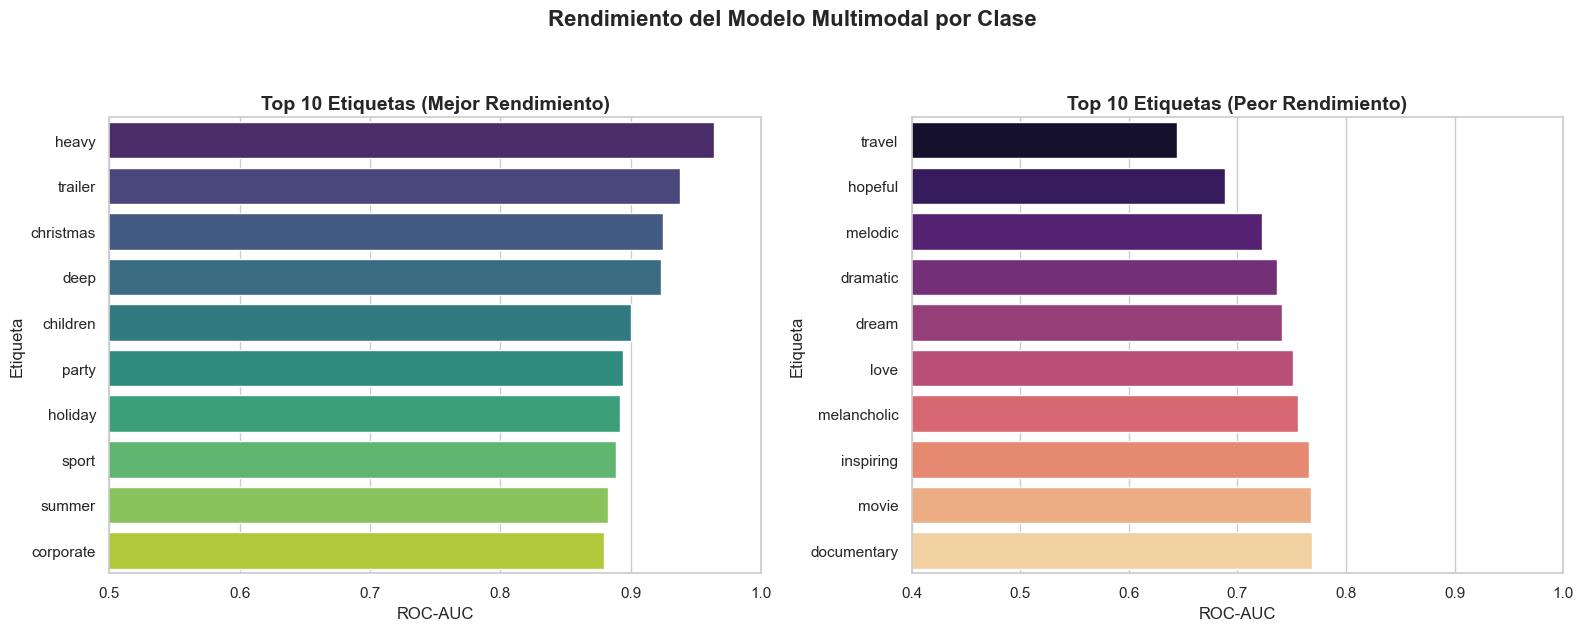

In [6]:
# Extraemos el Top 10 mejores y el Top 10 peores
top_10 = df_resultados.head(10)
bottom_10 = df_resultados.tail(10).sort_values(by='ROC-AUC', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Las mejores
sns.barplot(data=top_10, x='ROC-AUC', y='Etiqueta', palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Etiquetas (Mejor Rendimiento)', fontsize=14, fontweight='bold')
axes[0].set_xlim(0.5, 1.0)

# Gráfico 2: Las peores (Análisis de fallos)
sns.barplot(data=bottom_10, x='ROC-AUC', y='Etiqueta', palette='magma', ax=axes[1])
axes[1].set_title('Top 10 Etiquetas (Peor Rendimiento)', fontsize=14, fontweight='bold')
axes[1].set_xlim(0.4, 1.0) # 0.5 es aleatorio, por debajo es peor que tirar una moneda

plt.suptitle('Rendimiento del Modelo Multimodal por Clase', fontsize=16, fontweight='bold', y=1.05)
plt.savefig('multimodal_performance.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# CELDA 7: F1-Score con Umbral Óptimo por Clase
# ──────────────────────────────────────────────
valid_cols = [i for i in range(y_true.shape[1]) if len(np.unique(y_true[:, i])) > 1]

roc_auc_macro = roc_auc_score(y_true[:, valid_cols], y_score[:, valid_cols], average='macro')
roc_auc_micro = roc_auc_score(y_true[:, valid_cols], y_score[:, valid_cols], average='micro')
pr_auc_macro  = average_precision_score(y_true[:, valid_cols], y_score[:, valid_cols], average='macro')
pr_auc_micro  = average_precision_score(y_true[:, valid_cols], y_score[:, valid_cols], average='micro')

print("Optimizando umbrales por clase para F1...")
best_thresholds = np.full(y_true.shape[1], 0.5)
for c in valid_cols:
    best_f1, best_th = 0.0, 0.5
    for th in np.arange(0.05, 0.95, 0.05):
        preds_bin = (y_score[:, c] >= th).astype(int)
        score = f1_score(y_true[:, c], preds_bin, zero_division=0)
        if score > best_f1:
            best_f1, best_th = score, th
    best_thresholds[c] = best_th

y_pred_bin = (y_score >= best_thresholds).astype(int)
f1_macro   = f1_score(y_true, y_pred_bin, average='macro', zero_division=0)
f1_micro   = f1_score(y_true, y_pred_bin, average='micro', zero_division=0)

print("\n╔═══════════════════════════════════════════════════════╗")
print("║     MÉTRICAS FINALES — Late Fusion Multimodal          ║")
print("╠═══════════════════════════════════════════════════════╣")
print(f"║  ROC-AUC Macro:   {roc_auc_macro:.4f}                           ║")
print(f"║  ROC-AUC Micro:   {roc_auc_micro:.4f}                           ║")
print(f"║  PR-AUC  Macro:   {pr_auc_macro:.4f}                           ║")
print(f"║  PR-AUC  Micro:   {pr_auc_micro:.4f}                           ║")
print(f"║  F1-Score Macro:  {f1_macro:.4f}  (umbral óptimo/clase)  ║")
print(f"║  F1-Score Micro:  {f1_micro:.4f}  (umbral óptimo/clase)  ║")
print("╠═══════════════════════════════════════════════════════╣")
print(f"║  Baseline VGG-ish (MediaEval 2021):   ROC-AUC=0.725    ║")
print(f"║  Δ vs Baseline:  {roc_auc_macro - 0.725:+.4f}                          ║")
print("╚═══════════════════════════════════════════════════════╝")

# Guardar para la tabla comparativa
np.save(SRC_DIR / "multimodal_y_true.npy",  y_true)
np.save(SRC_DIR / "multimodal_y_score.npy", y_score)

In [ ]:
# CELDA 8: Curvas de Aprendizaje del Modelo Multimodal
# ──────────────────────────────────────────────────────
# Requiere que train_multimodal.py haya guardado history_multimodal.csv.
# Si el archivo no existe, es que el entrenamiento fue previo a esta corrección:
# vuelve a entrenar con el script corregido.

history_path = SRC_DIR / "history_multimodal.csv"

if history_path.exists():
    df_hist = pd.read_csv(history_path)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    ax1.plot(df_hist['epoch'], df_hist['train_loss'], label='Train Loss', color='#1f77b4', lw=2)
    ax1.plot(df_hist['epoch'], df_hist['val_loss'],   label='Val Loss',   color='#ff7f0e', lw=2)
    ax1.set_title('Evolución de la Pérdida (Late Fusion)', fontweight='bold')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('BCEWithLogitsLoss')
    ax1.legend()

    ax2.plot(df_hist['epoch'], df_hist['val_auc'], label='Val ROC-AUC',
             color='#2ca02c', lw=2, marker='o', markersize=4)
    ax2.axhline(y=df_hist['val_auc'].max(), color='red', linestyle='--', alpha=0.5,
                label=f'Máx AUC: {df_hist["val_auc"].max():.4f}')
    ax2.set_title('ROC-AUC en Validación (Late Fusion)', fontweight='bold')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('ROC-AUC Macro')
    ax2.legend()

    plt.tight_layout()
    plt.savefig("multimodal_learning_curves.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Mejor época: {df_hist.loc[df_hist['val_auc'].idxmax(), 'epoch']} | "
          f"Mejor AUC: {df_hist['val_auc'].max():.4f}")
else:
    print("[AVISO] history_multimodal.csv no encontrado.")
    print("Reentrena el modelo con train_multimodal.py corregido para obtener el historial.")

In [ ]:
# CELDA 9: TABLA COMPARATIVA GLOBAL — Todos los Modelos vs Baseline
# ════════════════════════════════════════════════════════════════════
# Esta celda carga los resultados .npy guardados por cada notebook
# y construye la tabla comparativa central del TFG.
# Responde directamente a RQ1 (arquitecturas) y RQ2 (multimodalidad).

def compute_all_metrics(y_true, y_score, model_name):
    """Calcula ROC-AUC, PR-AUC y F1 con umbral óptimo por clase."""
    valid_cols = [i for i in range(y_true.shape[1]) if len(np.unique(y_true[:, i])) > 1]
    roc_macro = roc_auc_score(y_true[:, valid_cols], y_score[:, valid_cols], average='macro')
    roc_micro = roc_auc_score(y_true[:, valid_cols], y_score[:, valid_cols], average='micro')
    pr_macro  = average_precision_score(y_true[:, valid_cols], y_score[:, valid_cols], average='macro')
    # Umbral óptimo por clase
    best_th = np.full(y_true.shape[1], 0.5)
    for c in valid_cols:
        best_f1 = 0.0
        for th in np.arange(0.05, 0.95, 0.05):
            s = f1_score(y_true[:, c], (y_score[:, c] >= th).astype(int), zero_division=0)
            if s > best_f1:
                best_f1, best_th[c] = s, th
    f1_macro = f1_score(y_true, (y_score >= best_th).astype(int), average='macro', zero_division=0)
    return {'Modelo': model_name, 'ROC-AUC Macro': roc_macro,
            'ROC-AUC Micro': roc_micro, 'PR-AUC Macro': pr_macro, 'F1 Macro': f1_macro}

# ── Cargar resultados guardados por cada notebook ──
rows = [{'Modelo': 'VGG-ish (Baseline MediaEval 2021)',
         'ROC-AUC Macro': 0.725, 'ROC-AUC Micro': '-', 'PR-AUC Macro': '-', 'F1 Macro': '-'}]

# Zero-Shot CLAP (resultados de notebook 7)
clap_true_path  = PROJECT_ROOT / 'data' / 'embeddings' / 'zero_shot_y_true_global.npy'
clap_score_path = PROJECT_ROOT / 'data' / 'embeddings' / 'zero_shot_y_score_global.npy'
if clap_true_path.exists():
    rows.append(compute_all_metrics(
        np.load(clap_true_path), np.load(clap_score_path), 'CLAP (Zero-Shot)'))
else:
    rows.append({'Modelo': 'CLAP (Zero-Shot)', 'ROC-AUC Macro': '—',
                 'ROC-AUC Micro': '—', 'PR-AUC Macro': '—', 'F1 Macro': '—'})

for nombre, prefix in [('PANNs CNN14', 'panns'), ('AST Transformer', 'ast'),
                        ('Late Fusion Multimodal', 'multimodal')]:
    t_path = SRC_DIR / f"{prefix}_y_true.npy"
    s_path = SRC_DIR / f"{prefix}_y_score.npy"
    if t_path.exists() and s_path.exists():
        rows.append(compute_all_metrics(np.load(t_path), np.load(s_path), nombre))
    else:
        rows.append({'Modelo': nombre, 'ROC-AUC Macro': '(pendiente)',
                     'ROC-AUC Micro': '—', 'PR-AUC Macro': '—', 'F1 Macro': '—'})

df_cmp = pd.DataFrame(rows).set_index('Modelo')

# ── Formatear y visualizar ──
print("\n" + "═"*70)
print("   TABLA COMPARATIVA GLOBAL — TFG Emociones Musicales")
print("═"*70)
display(df_cmp.style
        .format({c: '{:.4f}' for c in df_cmp.select_dtypes('float').columns})
        .highlight_max(subset=df_cmp.select_dtypes('float').columns, color='#d4edda')
        .set_caption("Evaluación en split de validación oficial (split-0, libre de Artist Effect)"))

# ── Gráfico de barras comparativo ──
df_plot = df_cmp[df_cmp['ROC-AUC Macro'].apply(lambda x: isinstance(x, float))].copy()
df_plot.index.name = 'Modelo'
df_plot = df_plot.reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, color in zip(axes,
                           ['ROC-AUC Macro', 'PR-AUC Macro', 'F1 Macro'],
                           ['#3498db', '#e67e22', '#2ecc71']):
    sns.barplot(data=df_plot, x=col, y='Modelo', color=color, ax=ax)
    ax.set_title(col, fontweight='bold')
    ax.set_xlim(0, 1)
    # Línea baseline
    ax.axvline(x=0.725, color='red', linestyle='--', alpha=0.5, label='VGG-ish 0.725')
    for bar in ax.patches:
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=9)

axes[0].legend(loc='lower right')
plt.suptitle('Comparativa de Modelos — TFG Reconocimiento de Emociones Musicales',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("tabla_comparativa_modelos.png", dpi=300, bbox_inches='tight')
plt.show()